# Projeto

Objetivo: Armazenar os gastos (até o momento) por deputado federal.

1. Obter os dados
2. Efetuar os ajustes necessários
3. Armazenar no sqlite

---
### Extração dos dados
---

In [9]:
import pandas as pd
import requests

In [10]:
url = "https://dadosabertos.camara.leg.br/api/v2/deputados?ordem=ASC&ordenarPor=nome"
resultado = requests.get(url)

In [11]:
deputados = pd.DataFrame(resultado.json()['dados'])

In [12]:
deputados.head()

,id,uri,nome,siglaPartido,uriPartido,siglaUf,idLegislatura,urlFoto,email
0,204379,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
1,220714,https://dadosabertos.camara.leg.br/api/v2/depu...,Adail Filho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AM,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adailfilho@camara.leg.br
2,221328,https://dadosabertos.camara.leg.br/api/v2/depu...,Adilson Barroso,PL,https://dadosabertos.camara.leg.br/api/v2/part...,SP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adilsonbarroso@camara.leg.br
3,204560,https://dadosabertos.camara.leg.br/api/v2/depu...,Adolfo Viana,PSDB,https://dadosabertos.camara.leg.br/api/v2/part...,BA,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adolfoviana@camara.leg.br
4,204528,https://dadosabertos.camara.leg.br/api/v2/depu...,Adriana Ventura,NOVO,https://dadosabertos.camara.leg.br/api/v2/part...,SP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adrianaventura@camara.leg.br


In [13]:
deputados.shape

(513, 9)

In [27]:
gastos = []
for id in deputados.id:
    url_despesa = "https://dadosabertos.camara.leg.br/api/v2/deputados/"+str(id)+"/despesas?ordem=ASC"
    resposta = requests.get(url_despesa)
    gasto = pd.DataFrame(resposta.json()['dados'])
    gasto['id'] = id
    gastos.append(gasto)

In [28]:
len(gastos)

513

In [29]:
len(gastos[20])

15

In [30]:
gastos[0]

,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,urlDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,numRessarcimento,codLote,parcela,id
0,2025,11,COMBUSTÍVEIS E LUBRIFICANTES.,8030573,Nota Fiscal Eletrônica,4,2025-11-27T00:00:00,6515,195.02,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,195.02,0.0,,2197722,0,204379
1,2025,11,COMBUSTÍVEIS E LUBRIFICANTES.,8024781,Nota Fiscal Eletrônica,4,2025-11-27T00:00:00,6516,355.83,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,355.83,0.0,,2194626,0,204379
2,2025,11,COMBUSTÍVEIS E LUBRIFICANTES.,8030565,Nota Fiscal Eletrônica,4,2025-11-28T00:00:00,6523,300.00,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,300.00,0.0,,2197722,0,204379
3,2025,12,COMBUSTÍVEIS E LUBRIFICANTES.,8035830,Nota Fiscal Eletrônica,4,2025-12-29T07:11:37,6633,343.73,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,343.73,0.0,,2200466,0,204379
4,2025,12,COMBUSTÍVEIS E LUBRIFICANTES.,8035209,Nota Fiscal Eletrônica,4,2025-12-19T00:06:23,15632,344.15,http://www.camara.leg.br/cota-parlamentar/nota...,075 - COLORADO - CASCOL COMBUSTIVEIS PARA VEIC...,00306597007533,344.15,0.0,,2200111,0,204379
5,2025,12,COMBUSTÍVEIS E LUBRIFICANTES.,8030541,Nota Fiscal Eletrônica,4,2025-12-10T00:00:00,368214,150.00,http://www.camara.leg.br/cota-parlamentar/nota...,AUTO POSTO 303 NORTE LTDA,38194212000120,150.00,0.0,,2197723,0,204379
6,2025,12,COMBUSTÍVEIS E LUBRIFICANTES.,8030550,Nota Fiscal Eletrônica,4,2025-12-04T00:00:00,61762,300.00,http://www.camara.leg.br/cota-parlamentar/nota...,AUTO POSTO 303 NORTE LTDA,38194212000120,300.00,0.0,,2197723,0,204379
7,2025,12,COMBUSTÍVEIS E LUBRIFICANTES.,8035211,Nota Fiscal Eletrônica,4,2025-12-17T17:29:45,62611,400.00,http://www.camara.leg.br/cota-parlamentar/nota...,AUTO POSTO 303 NORTE LTDA,38194212000120,400.00,0.0,,2200111,0,204379
8,2025,12,COMBUSTÍVEIS E LUBRIFICANTES.,8030536,Nota Fiscal Eletrônica,4,2025-12-08T00:00:00,98262,328.10,http://www.camara.leg.br/cota-parlamentar/nota...,AUTO POSTO DE COMBUSTIVEL FLAMINGO LTDA,36180754000118,328.10,0.0,,2197723,0,204379
9,2025,12,COMBUSTÍVEIS E LUBRIFICANTES.,8035827,Nota Fiscal Eletrônica,4,2025-12-29T17:06:42,49010,384.59,http://www.camara.leg.br/cota-parlamentar/nota...,AUTO POSTO FENIX ODJ LTDA,25004046000290,384.59,0.0,,2200466,0,204379


---
### Transformação dos dados
---

In [31]:
total = pd.concat(gastos)

In [32]:
total.head()

,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,urlDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,numRessarcimento,codLote,parcela,id
0,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8030573,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,6515,195.02,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,195.02,0.0,,2197722.0,0.0,204379
1,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8024781,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,6516,355.83,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,355.83,0.0,,2194626.0,0.0,204379
2,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8030565,Nota Fiscal Eletrônica,4.0,2025-11-28T00:00:00,6523,300.00,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,300.00,0.0,,2197722.0,0.0,204379
3,2025.0,12.0,COMBUSTÍVEIS E LUBRIFICANTES.,8035830,Nota Fiscal Eletrônica,4.0,2025-12-29T07:11:37,6633,343.73,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,343.73,0.0,,2200466.0,0.0,204379
4,2025.0,12.0,COMBUSTÍVEIS E LUBRIFICANTES.,8035209,Nota Fiscal Eletrônica,4.0,2025-12-19T00:06:23,15632,344.15,http://www.camara.leg.br/cota-parlamentar/nota...,075 - COLORADO - CASCOL COMBUSTIVEIS PARA VEIC...,00306597007533,344.15,0.0,,2200111.0,0.0,204379


In [33]:
total.sample(3)

,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,urlDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,numRessarcimento,codLote,parcela,id
7,2025.0,12.0,PASSAGEM AÉREA - SIGEPA,1EFD732F-FB8E-46B0-993B-F9BAC7F749F5,Nota Fiscal,0.0,2025-12-01T00:00:00,9572262730604,2013.95,None,LATAM Airlines Brasil,,2013.95,0.0,0,0.0,0.0,160591
4,2025.0,12.0,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,8029630,Nota Fiscal,0.0,2025-12-10T00:00:00,00001683,2000.00,https://www.camara.leg.br/cota-parlamentar/doc...,EVAG COMUNICAÇÃO E TECNOLOGIA LTDA,15705697000173,2000.00,0.0,,2197293.0,0.0,204535
12,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8020236,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,440171,310.00,http://www.camara.leg.br/cota-parlamentar/nota...,AUTO POSTO DE COMBUSTIVEL FLAMINGO LTDA,36180754000118,310.00,0.0,,2192097.0,0.0,220545


In [ ]:
# valores ausentes?
total.isnull().sum()

ano                  0
mes                  0
tipoDespesa          0
codDocumento         0
tipoDocumento        0
codTipoDocumento     0
dataDocumento        0
numDocumento         0
valorDocumento       0
nomeFornecedor       0
cnpjCpfFornecedor    0
valorLiquido         0
valorGlosa           0
numRessarcimento     0
codLote              0
parcela              0
id                   0
dtype: int64

In [ ]:
# no exemplo da aula teve 158 valores ausentes na coluna "dataDocumento", mas no meu caso tem 1031 valores ausentes na coluna "urlDocumento".
del total['urlDocumento']

In [41]:
total.head()


,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,numRessarcimento,codLote,parcela,id
0,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8030573,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,6515,195.02,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,195.02,0.0,,2197722.0,0.0,204379
1,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8024781,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,6516,355.83,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,355.83,0.0,,2194626.0,0.0,204379
2,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8030565,Nota Fiscal Eletrônica,4.0,2025-11-28T00:00:00,6523,300.00,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,300.00,0.0,,2197722.0,0.0,204379
3,2025.0,12.0,COMBUSTÍVEIS E LUBRIFICANTES.,8035830,Nota Fiscal Eletrônica,4.0,2025-12-29T07:11:37,6633,343.73,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,343.73,0.0,,2200466.0,0.0,204379
4,2025.0,12.0,COMBUSTÍVEIS E LUBRIFICANTES.,8035209,Nota Fiscal Eletrônica,4.0,2025-12-19T00:06:23,15632,344.15,075 - COLORADO - CASCOL COMBUSTIVEIS PARA VEIC...,00306597007533,344.15,0.0,,2200111.0,0.0,204379


In [42]:
total.numRessarcimento.value_counts()

numRessarcimento
     6660
0     920
Name: count, dtype: int64

In [43]:
total.shape

(7580, 17)

In [44]:
del total['numRessarcimento']

In [45]:
total.head()


,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,codLote,parcela,id
0,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8030573,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,6515,195.02,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,195.02,0.0,2197722.0,0.0,204379
1,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8024781,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,6516,355.83,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,355.83,0.0,2194626.0,0.0,204379
2,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8030565,Nota Fiscal Eletrônica,4.0,2025-11-28T00:00:00,6523,300.00,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,300.00,0.0,2197722.0,0.0,204379
3,2025.0,12.0,COMBUSTÍVEIS E LUBRIFICANTES.,8035830,Nota Fiscal Eletrônica,4.0,2025-12-29T07:11:37,6633,343.73,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,343.73,0.0,2200466.0,0.0,204379
4,2025.0,12.0,COMBUSTÍVEIS E LUBRIFICANTES.,8035209,Nota Fiscal Eletrônica,4.0,2025-12-19T00:06:23,15632,344.15,075 - COLORADO - CASCOL COMBUSTIVEIS PARA VEIC...,00306597007533,344.15,0.0,2200111.0,0.0,204379


In [49]:
print(total.shape)
total.drop_duplicates()
print(total.shape)

(7580, 16)
(7580, 16)


In [50]:
total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7580 entries, 0 to 14
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ano                7580 non-null   float64
 1   mes                7580 non-null   float64
 2   tipoDespesa        7580 non-null   object 
 3   codDocumento       7580 non-null   object 
 4   tipoDocumento      7580 non-null   object 
 5   codTipoDocumento   7580 non-null   float64
 6   dataDocumento      7580 non-null   object 
 7   numDocumento       7580 non-null   object 
 8   valorDocumento     7580 non-null   float64
 9   nomeFornecedor     7580 non-null   object 
 10  cnpjCpfFornecedor  7580 non-null   object 
 11  valorLiquido       7580 non-null   float64
 12  valorGlosa         7580 non-null   float64
 13  codLote            7580 non-null   float64
 14  parcela            7580 non-null   float64
 15  id                 7580 non-null   int64  
dtypes: float64(8), int64(1), object

In [51]:
total.describe()

,ano,mes,codTipoDocumento,valorDocumento,valorLiquido,valorGlosa,codLote,parcela,id
count,7580.000000,7580.000000,7580.000000,7580.000000,7580.000000,7580.000000,7.580000e+03,7580.000000,7580.000000
mean,2025.122559,10.726781,1.680079,2339.667203,2297.741558,5.257080,1.935014e+06,0.010158,182247.154617
std,0.327952,2.859538,1.860315,5679.935708,5635.059911,64.594566,7.192956e+05,0.100282,48360.779001
min,2025.000000,1.000000,0.000000,-4221.820000,-4221.820000,0.000000,0.000000e+00,0.000000,62881.000000
25%,2025.000000,11.000000,0.000000,200.000000,200.000000,0.000000,2.194872e+06,0.000000,160592.000000
50%,2025.000000,12.000000,1.000000,347.190000,343.840000,0.000000,2.198404e+06,0.000000,204449.000000
75%,2025.000000,12.000000,4.000000,2167.612500,2138.110000,0.000000,2.202202e+06,0.000000,220592.500000
max,2026.000000,12.000000,4.000000,93000.000000,93000.000000,2083.000000,2.238018e+06,1.000000,235800.000000


In [52]:
total.nomeFornecedor.value_counts()

nomeFornecedor
LATAM Airlines Brasil                                       549
Gol Linhas Aéreas                                           259
AUTO POSTO CINCO ESTRELAS LTDA                              129
Azul Linhas Aéreas                                          107
031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA     91
                                                           ... 
POSTO BOGO LTDA - XV                                          1
POSTO 4 IRMAOS JL LTDA                                        1
OCTA DITRIBUIDORA E COMERCIAL IMPORTADORA EIRELI              1
HANNA COMERCIO DE MÓVEIS PLANEJADOS LTDA                      1
A F L COMERCIO DE DERIVADOS DE PETROLEO                       1
Name: count, Length: 3038, dtype: int64

In [56]:
total.nomeFornecedor = [str(fornecedor).upper().replace("S.A.", "S.A").replace("S/A", "S.A") 
for fornecedor in total.nomeFornecedor]

In [57]:
total.nomeFornecedor.value_counts()

nomeFornecedor
LATAM AIRLINES BRASIL                                       549
GOL LINHAS AÉREAS                                           259
AUTO POSTO CINCO ESTRELAS LTDA                              129
AZUL LINHAS AÉREAS                                          107
031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA     91
                                                           ... 
AGORA SOU VISTO AGENCIA DE COMUNICAÇÃO LTDA                   1
POSTO Z1 LTDA                                                 1
POSTO LAGOMAR LTDA                                            1
POSTO BOGO LTDA - XV                                          1
POSTO 4 IRMAOS JL LTDA                                        1
Name: count, Length: 3023, dtype: int64

---
### Carregando os dados
---

In [59]:
from sqlalchemy import create_engine

In [60]:
engine = create_engine('sqlite:///dados_aberto.db')

In [61]:
deputados.to_sql('deputados', engine)

513

In [62]:
total.to_sql('despesas_total', engine)

7580

### Análise

In [63]:
total = pd.read_sql("select * from despesas_total;", engine)

In [64]:
total.head()

,index,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,codLote,parcela,id
0,0,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8030573,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,6515,195.02,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,195.02,0.0,2197722.0,0.0,204379
1,1,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8024781,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,6516,355.83,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,355.83,0.0,2194626.0,0.0,204379
2,2,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8030565,Nota Fiscal Eletrônica,4.0,2025-11-28T00:00:00,6523,300.00,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,300.00,0.0,2197722.0,0.0,204379
3,3,2025.0,12.0,COMBUSTÍVEIS E LUBRIFICANTES.,8035830,Nota Fiscal Eletrônica,4.0,2025-12-29T07:11:37,6633,343.73,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,343.73,0.0,2200466.0,0.0,204379
4,4,2025.0,12.0,COMBUSTÍVEIS E LUBRIFICANTES.,8035209,Nota Fiscal Eletrônica,4.0,2025-12-19T00:06:23,15632,344.15,075 - COLORADO - CASCOL COMBUSTIVEIS PARA VEIC...,00306597007533,344.15,0.0,2200111.0,0.0,204379


In [65]:
deputados = pd.read_sql("select * from deputados;", engine)

In [66]:
total = total.merge(deputados, on='id')

In [67]:
total.head()

,index_x,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,...,id,index_y,uri,nome,siglaPartido,uriPartido,siglaUf,idLegislatura,urlFoto,email
0,0,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8030573,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,6515,195.02,...,204379,0,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
1,1,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8024781,Nota Fiscal Eletrônica,4.0,2025-11-27T00:00:00,6516,355.83,...,204379,0,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
2,2,2025.0,11.0,COMBUSTÍVEIS E LUBRIFICANTES.,8030565,Nota Fiscal Eletrônica,4.0,2025-11-28T00:00:00,6523,300.00,...,204379,0,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
3,3,2025.0,12.0,COMBUSTÍVEIS E LUBRIFICANTES.,8035830,Nota Fiscal Eletrônica,4.0,2025-12-29T07:11:37,6633,343.73,...,204379,0,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
4,4,2025.0,12.0,COMBUSTÍVEIS E LUBRIFICANTES.,8035209,Nota Fiscal Eletrônica,4.0,2025-12-19T00:06:23,15632,344.15,...,204379,0,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br


In [72]:
gastos_deputados = total.groupby(['nome']).sum()[['valorDocumento' , 'valorLiquido']]

In [75]:
gastos_deputados = gastos_deputados.sort_values('valorDocumento', ascending=False)

In [76]:
gastos_deputados.head(10)

,valorDocumento,valorLiquido
nome,,
Eunício Oliveira,301139.00,301139.00
Glaustin da Fokus,215525.30,215525.30
Delegado Éder Mauro,208714.25,208714.25
Fábio Macedo,204401.01,204401.01
André Fernandes,193684.80,193684.80
Amanda Gentil,177596.72,177596.72
Marcos Aurélio Sampaio,152900.00,152900.00
Cleber Verde,152354.02,152354.02
Dr. Victor Linhalis,151926.54,151849.52


In [77]:
gastos_deputados.tail(10)

,valorDocumento,valorLiquido
nome,,
André Janones,3048.10,3048.10
Franciane Bayer,3006.64,3006.64
Missionário José Olimpio,2898.07,2898.07
Miguel Ângelo,2740.28,2740.28
Marina Silva,2645.06,2645.06
Marcos Soares,2514.75,2514.75
Simone Marquetto,2018.10,2018.10
Pastor Sargento Isidório,1989.55,1989.55
Marcio Alvino,1828.91,1828.91


In [ ]:
%matplotlib inline 
''' 
    %matplotlib inline é um comando mágico do Jupyter Notebook que permite que os gráficos sejam exibidos diretamente no notebook, em vez de abrir em uma janela separada.
'''

<Axes: xlabel='nomeFornecedor'>

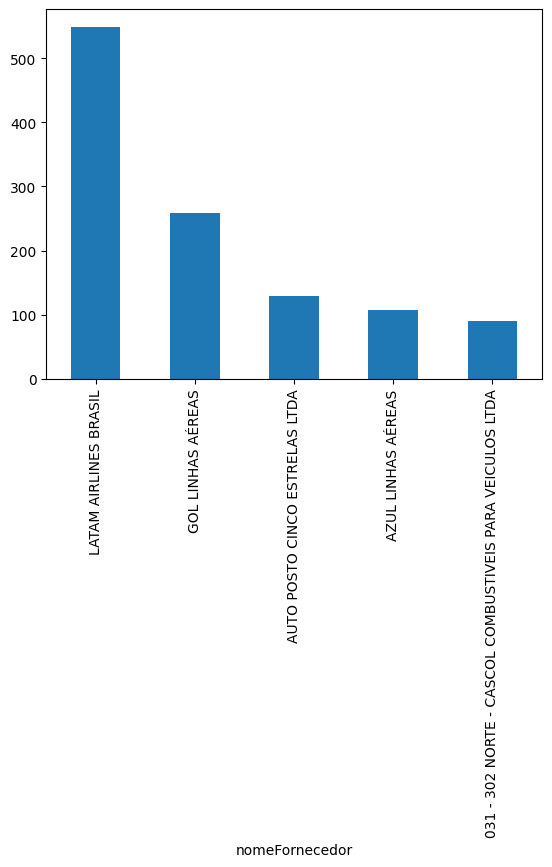

In [80]:
total.nomeFornecedor.value_counts().head()[:10].plot(kind="bar")